Cross validation: why a single train/test split is unreliable, and how KFold, StratifiedKFold, GridSearchCV, and RandomizedSearchCV give more trustworthy estimates and tuning on the wine dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

wine = load_wine()
X, y = wine.data, wine.target
print("Class distribution:", np.bincount(y))

Class distribution: [59 71 48]


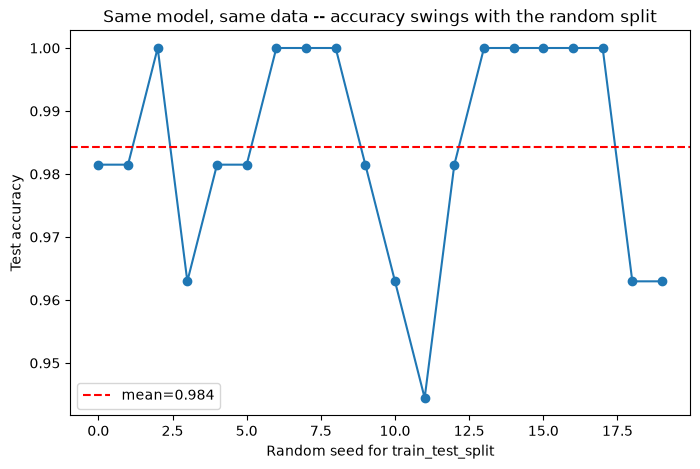

Accuracy range across seeds: 0.944 to 1.000
A single split can make a model look better OR worse than it really is, just by luck of the split.


In [2]:
# Problem: a single train/test split's accuracy depends heavily on the random seed
single_split_accs = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=seed)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_tr, y_tr)
    single_split_accs.append(clf.score(X_te, y_te))

plt.figure(figsize=(8, 5))
plt.plot(single_split_accs, 'o-')
plt.axhline(np.mean(single_split_accs), color='red', linestyle='--', label=f'mean={np.mean(single_split_accs):.3f}')
plt.xlabel('Random seed for train_test_split')
plt.ylabel('Test accuracy')
plt.title('Same model, same data -- accuracy swings with the random split')
plt.legend()
plt.show()
print(f"Accuracy range across seeds: {min(single_split_accs):.3f} to {max(single_split_accs):.3f}")
print("A single split can make a model look better OR worse than it really is, just by luck of the split.")

In [3]:
# KFold: average performance over K different splits instead of trusting just one
kf = KFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(clf, X, y, cv=kf)
print("KFold scores per fold:", np.round(scores, 3))
print(f"Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")

KFold scores per fold: [1.    1.    0.944 0.971 1.   ]
Mean: 0.9832, Std: 0.0223


In [4]:
# StratifiedKFold: preserves class proportions in every fold -- important for imbalanced
# or multi-class data like this 3-class wine dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_strat = cross_val_score(clf, X, y, cv=skf)
print("StratifiedKFold scores per fold:", np.round(scores_strat, 3))
print(f"Mean: {scores_strat.mean():.4f}, Std: {scores_strat.std():.4f}")

# Show what plain KFold can do wrong on sorted/grouped data
y_sorted_idx = np.argsort(y)
X_sorted, y_sorted = X[y_sorted_idx], y[y_sorted_idx]
kf_unshuffled = KFold(n_splits=5, shuffle=False)
for i, (train_idx, test_idx) in enumerate(kf_unshuffled.split(X_sorted)):
    print(f"Fold {i}: test set class distribution = {np.bincount(y_sorted[test_idx], minlength=3)}")
print("\nWithout shuffling, folds can end up with skewed or missing classes entirely -- StratifiedKFold prevents this.")

StratifiedKFold scores per fold: [0.972 1.    0.972 0.943 1.   ]
Mean: 0.9775, Std: 0.0213
Fold 0: test set class distribution = [36  0  0]
Fold 1: test set class distribution = [23 13  0]
Fold 2: test set class distribution = [ 0 36  0]
Fold 3: test set class distribution = [ 0 22 13]
Fold 4: test set class distribution = [ 0  0 35]

Without shuffling, folds can end up with skewed or missing classes entirely -- StratifiedKFold prevents this.


In [5]:
# GridSearchCV: exhaustively try every combination, cross-validating each
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf'],
}
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)

print(f"Combinations tried: {len(grid.cv_results_['params'])}")
print("Best params:", grid.best_params_)
print(f"Best CV score: {grid.best_score_:.4f}")

Combinations tried: 16
Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.7421


In [6]:
# RandomizedSearchCV: sample a fixed number of random combinations instead of all of them --
# scales better when the hyperparameter space is large
param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
}
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_dist,
    n_iter=20, cv=5, scoring='accuracy', random_state=42,
)
random_search.fit(X, y)

print(f"Combinations tried: {len(random_search.cv_results_['params'])} (out of an effectively infinite grid)")
print("Best params:", random_search.best_params_)
print(f"Best CV score: {random_search.best_score_:.4f}")

Combinations tried: 20 (out of an effectively infinite grid)
Best params: {'max_depth': 13, 'min_samples_split': 18, 'n_estimators': 108}
Best CV score: 0.9722


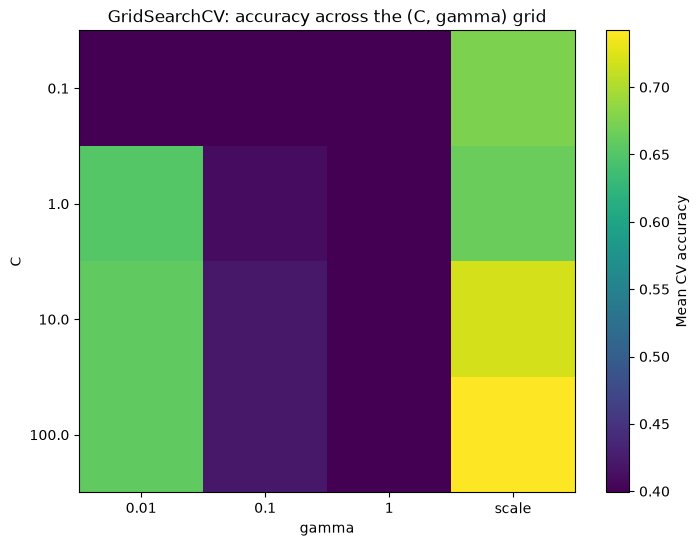

In [7]:
# Compare GridSearchCV's full results to see how sensitive the model is to each hyperparameter
results_df = pd.DataFrame(grid.cv_results_)
pivot = results_df.pivot_table(values='mean_test_score', index='param_C', columns='param_gamma')

plt.figure(figsize=(8, 6))
plt.imshow(pivot.values, cmap='viridis', aspect='auto')
plt.colorbar(label='Mean CV accuracy')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('gamma')
plt.ylabel('C')
plt.title('GridSearchCV: accuracy across the (C, gamma) grid')
plt.show()